# ch235 — Convolution and the Integral Transform

**Advanced Calculus Experiment 5.**

Convolution is the mathematical operation behind signal smoothing, image filtering, and — crucially — convolutional neural networks. It is defined as an integral transform:

```
(f * g)(t) = integral f(tau) * g(t - tau) dtau
```

Discretely, it is a sliding dot product. Understanding it bridges calculus and deep learning architecture.

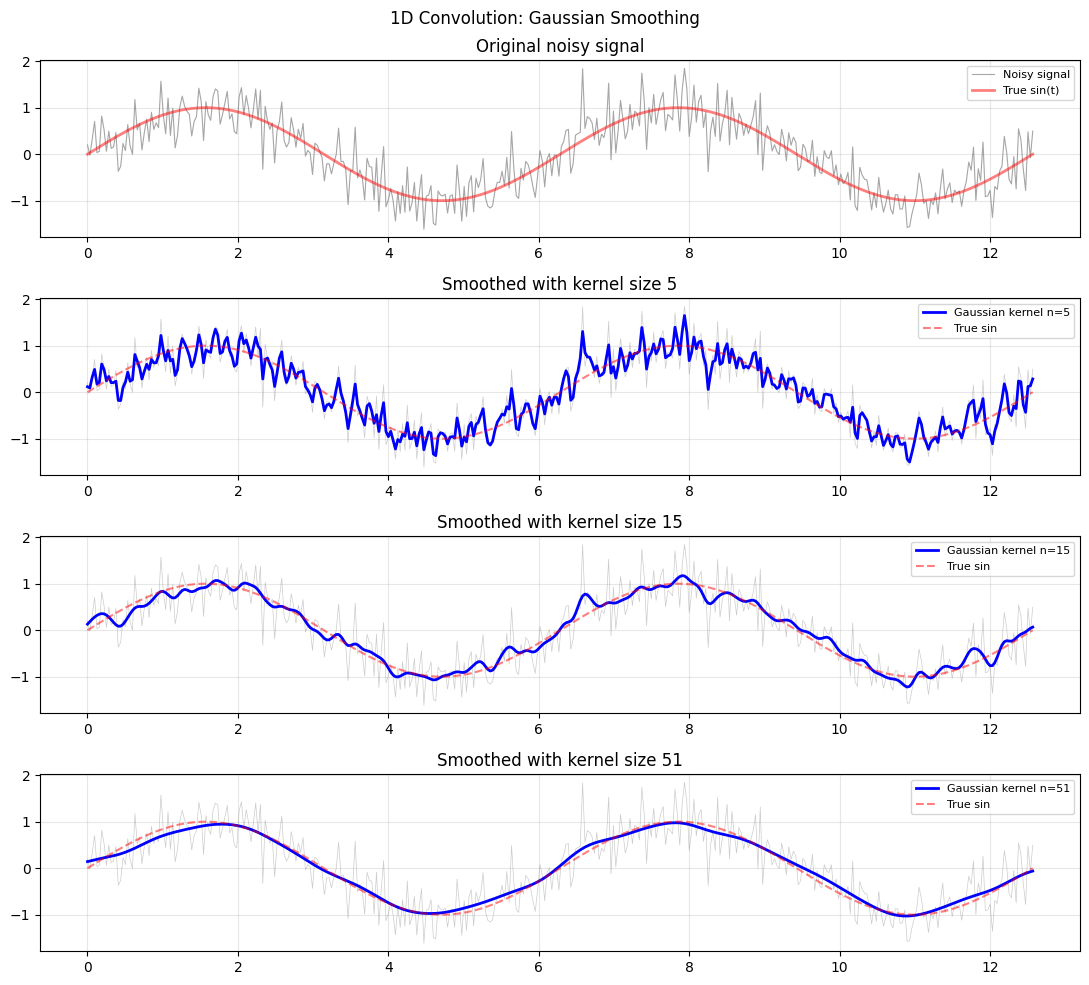

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

# ── 1D convolution: smoothing a noisy signal ──────────────────────────────
np.random.seed(42)
t = np.linspace(0, 4*np.pi, 400)
signal = np.sin(t) + np.random.normal(0, 0.4, len(t))

# Gaussian kernel
def gaussian_kernel(n, sigma):
    x = np.linspace(-3, 3, n)
    k = np.exp(-x**2 / (2*sigma**2))
    return k / k.sum()

kernel_sizes = [5, 15, 51]
kernels = [gaussian_kernel(n, sigma=1.0) for n in kernel_sizes]

fig, axes = plt.subplots(len(kernel_sizes)+1, 1, figsize=(11, 10))
axes[0].plot(t, signal, 'gray', lw=0.8, alpha=0.7, label='Noisy signal')
axes[0].plot(t, np.sin(t), 'r', lw=2, alpha=0.5, label='True sin(t)')
axes[0].legend(fontsize=8); axes[0].set_title('Original noisy signal'); axes[0].grid(True, alpha=0.3)

for ax, kernel, n in zip(axes[1:], kernels, kernel_sizes):
    smoothed = convolve(signal, kernel, mode='same')
    ax.plot(t, signal, 'gray', lw=0.5, alpha=0.4)
    ax.plot(t, smoothed, 'b', lw=2, label=f'Gaussian kernel n={n}')
    ax.plot(t, np.sin(t), 'r--', lw=1.5, alpha=0.5, label='True sin')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_title(f'Smoothed with kernel size {n}')

plt.suptitle('1D Convolution: Gaussian Smoothing', fontsize=12)
plt.tight_layout(); plt.savefig('ch235_conv1d.png', dpi=100); plt.show()


## 2D Convolution — Image Filtering

Image processing uses 2D convolution: slide a small kernel (filter) across the image, computing the dot product at each position. Different kernels perform different operations.

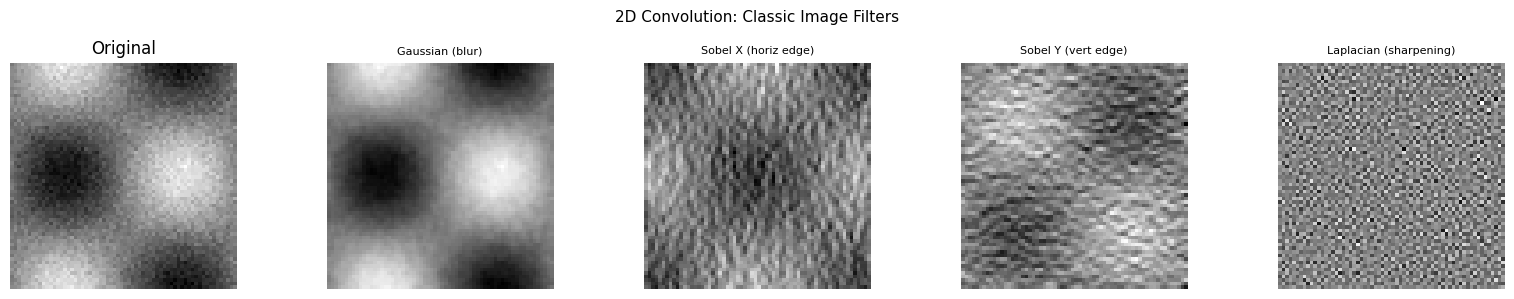

In [2]:
from scipy.ndimage import convolve as convolve2d

# Synthetic image: gradient + noise
size = 64
x_img = np.linspace(-3, 3, size)
XX, YY = np.meshgrid(x_img, x_img)
image = np.sin(XX) * np.cos(YY) + np.random.normal(0, 0.1, (size, size))
image = (image - image.min()) / (image.max() - image.min())

# Define filters
filters = {
    'Gaussian (blur)': np.outer(gaussian_kernel(5, 1.0), gaussian_kernel(5, 1.0)),
    'Sobel X (horiz edge)': np.array([[-1,0,1],[-2,0,2],[-1,0,1]]) / 4.0,
    'Sobel Y (vert edge)': np.array([[-1,-2,-1],[0,0,0],[1,2,1]]) / 4.0,
    'Laplacian (sharpening)': np.array([[0,-1,0],[-1,4,-1],[0,-1,0]]),
}

fig, axes = plt.subplots(1, len(filters)+1, figsize=(16, 3))
axes[0].imshow(image, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')

for ax, (name, kern) in zip(axes[1:], filters.items()):
    filtered = convolve2d(image, kern)
    ax.imshow(filtered, cmap='gray'); ax.set_title(name, fontsize=8); ax.axis('off')

plt.suptitle('2D Convolution: Classic Image Filters', fontsize=11)
plt.tight_layout(); plt.savefig('ch235_conv2d.png', dpi=100); plt.show()


## Convolution as a Linear Operation

Convolution is linear and shift-equivariant — the same operation applies at every position. This is why CNNs share weights: the same kernel is applied everywhere in the image, reducing parameters dramatically compared to a fully connected layer *(ch177 — Linear Layers in Deep Learning)*.

In [6]:
import numpy as np
from scipy.signal import convolve

def conv_as_matrix(x, k):
    n = len(x)
    m = len(k)

    pad = m // 2
    k_padded = np.pad(k, (n, n))  # extra padding to avoid short slices

    T = np.zeros((n, n))
    for i in range(n):
        start = n + pad - i
        T[i, :] = k_padded[start:start + n]  # always length n

    return T @ x


x_short = np.array([1.0, 2, 3, 4, 5, 4, 3, 2, 1])
k_short = np.array([0.25, 0.5, 0.25])

conv_scipy = convolve(x_short, k_short, mode='same')
conv_matrix = conv_as_matrix(x_short, k_short)

print("Signal:          ", x_short)
print("scipy convolve:  ", np.round(conv_scipy, 4))
print("Matrix multiply: ", np.round(conv_matrix, 4))
print(f"Match: {np.allclose(conv_scipy, conv_matrix, atol=1e-10)}")

Signal:           [1. 2. 3. 4. 5. 4. 3. 2. 1.]
scipy convolve:   [1.  2.  3.  4.  4.5 4.  3.  2.  1. ]
Matrix multiply:  [1.  2.  3.  4.  4.5 4.  3.  2.  1. ]
Match: True


## Summary

| Concept | Key Idea |
|---|---|
| Convolution | Sliding dot product (integral transform in continuous case) |
| Gaussian kernel | Smoothing — weighted average of neighbours |
| Sobel kernel | Edge detection — difference of neighbouring rows/cols |
| Toeplitz structure | Convolution = sparse matrix multiplication |
| CNN kernels | Learned filters trained by backpropagation |

**Forward reference:** ch291 — Optimisation Methods (Part IX) includes training convolutional layers using the same gradient descent machinery from ch227.